In [41]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import joblib

In [42]:
df = pd.read_csv(
    "../data/processed/feature_engineered_shots.csv"
)

df.head()

,minute,second,period,under_pressure,shot_first_time,shot_one_on_one,shot_open_goal,shot_deflected,x,y,...,shot_technique_Volley,play_pattern_From Counter,play_pattern_From Free Kick,play_pattern_From Goal Kick,play_pattern_From Keeper,play_pattern_From Kick Off,play_pattern_From Throw In,play_pattern_Other,play_pattern_Regular Play,shot_distance
0,3,36,1,1,0,0,0,0,106.7,42.1,...,0,0,1,0,0,0,0,0,0,13.464769
1,6,10,1,0,1,0,0,0,109.1,35.5,...,0,0,0,0,0,0,0,0,0,11.792370
2,7,8,1,0,0,0,0,0,113.6,23.8,...,0,0,0,0,0,0,0,0,1,17.418381
3,13,4,1,0,0,0,0,0,91.8,40.2,...,0,0,0,0,0,0,0,0,0,28.200709
4,20,1,1,0,0,0,0,0,111.0,31.3,...,0,0,0,0,0,0,0,0,0,12.517588


In [43]:
X = df.drop(columns=
            ["goal",
             "end_x",
             "end_y"
            ]
)
y = df["goal"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [46]:
#training logistic regression
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [47]:
y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(
    X_test_scaled
)[:, 1]

In [48]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.7914812460267006

ROC-AUC:
0.8195699178362229

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.81      0.87      1390
           1       0.32      0.68      0.43       183

    accuracy                           0.79      1573
   macro avg       0.63      0.74      0.65      1573
weighted avg       0.88      0.79      0.82      1573



In [49]:
import joblib

joblib.dump(
    log_model,
    "../models/logistic_regression_xg.pkl"
)

print("Model saved successfully")

Model saved successfully


In [50]:
feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "../models/feature_columns.pkl"
)

print("Feature columns saved")

Feature columns saved


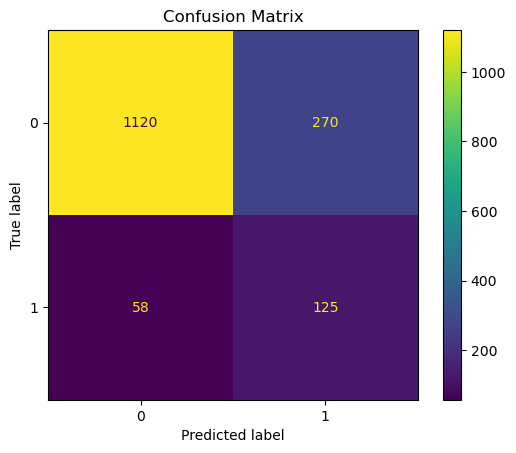

In [51]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="viridis")

plt.title("Confusion Matrix")
plt.show()

C:\Users\joshi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


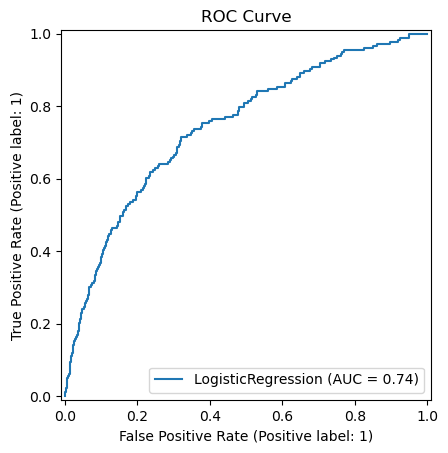

In [52]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    log_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

In [53]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']